# Part 4

In [1]:
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, avg, count, window, to_timestamp
from pyspark.sql.types import DoubleType

HOST_IP = "10.248.16.109"
KAFKA_BROKER = "localhost:9092"
TOPIC = "journey.gyroscope"

existing = SparkSession.getActiveSession()
if existing:
    existing.stop()

spark = (
    SparkSession.builder
    .appName("Journey-Part4")
    .master(f"spark://{HOST_IP}:7077")
    .config("spark.driver.host", HOST_IP)
    .config("spark.driver.bindAddress", HOST_IP)
    .config("spark.eventLog.enabled", "true")
    .config("spark.eventLog.dir", "file:///tmp/spark-events")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)
spark


In [2]:
df_raw = (
    spark.readStream
    .format("kafka")
    .option("kafka.bootstrap.servers", KAFKA_BROKER)
    .option("subscribe", TOPIC)
    .option("startingOffsets", "earliest")
    .load()
)

df_parsed = (
    df_raw
    .select(split(col("value").cast("string"), ",").alias("f"))
    .select(
        to_timestamp((col("f")[0].cast("long") / 1000).cast("long")).alias("zeit"),
        col("f")[1].cast(DoubleType()).alias("gx"),
        col("f")[2].cast(DoubleType()).alias("gy"),
        col("f")[3].cast(DoubleType()).alias("gz"),
        col("f")[4].cast(DoubleType()).alias("absolute"),
    )
)


In [3]:
df_result = (
    df_parsed
    .withWatermark("zeit", "10 seconds")
    .groupBy(window(col("zeit"), "1 second"))
    .agg(
        avg("absolute").alias("avg_absolute"),
        avg("gx").alias("avg_gx"),
        avg("gy").alias("avg_gy"),
        avg("gz").alias("avg_gz"),
        count("absolute").alias("n_samples"),
    )
    .select(
        col("window.start").alias("fenster_start"),
        col("window.end").alias("fenster_ende"),
        "avg_absolute", "avg_gx", "avg_gy", "avg_gz", "n_samples",
    )
)


In [4]:
query = (
    df_result.writeStream
    .outputMode("complete")
    .format("memory")
    .queryName("gyro_results")
    .trigger(processingTime="5 seconds")
    .start()
)
print("Stream started. Waiting for data...")

Stream started. Waiting for data...


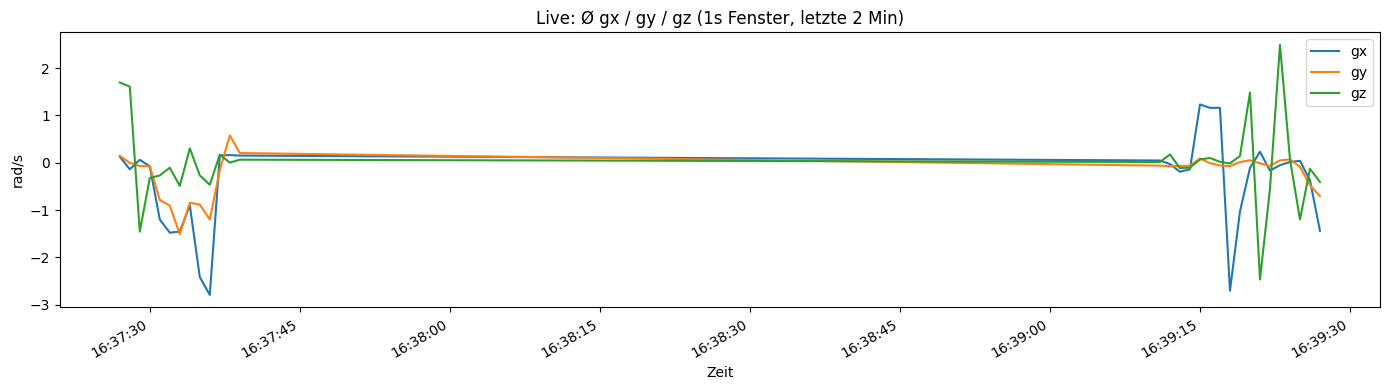

Poll 120/120 – 30 Fenster sichtbar, letzte Samples: 46


In [5]:
import pandas as pd

POLLS = 120
WINDOW_MINUTES = 2

for i in range(POLLS):
    time.sleep(5)
    pdf = spark.sql("SELECT * FROM gyro_results ORDER BY fenster_start").toPandas()
    clear_output(wait=True)

    if len(pdf) == 0:
        print(f"Poll {i+1}/{POLLS} – no data yet, waiting...")
        continue

    cutoff = pdf["fenster_start"].max() - pd.Timedelta(minutes=WINDOW_MINUTES)
    pdf = pdf[pdf["fenster_start"] >= cutoff]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(pdf["fenster_start"], pdf["avg_gx"], label="gx")
    ax.plot(pdf["fenster_start"], pdf["avg_gy"], label="gy")
    ax.plot(pdf["fenster_start"], pdf["avg_gz"], label="gz")
    ax.set_title("Live: Ø gx / gy / gz (1s Fenster, letzte 2 Min)")
    ax.set_xlabel("Zeit")
    ax.set_ylabel("rad/s")
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()
    print(f"Poll {i+1}/{POLLS} – {len(pdf)} Fenster sichtbar, letzte Samples: {pdf['n_samples'].iloc[-1]}")


In [6]:
query.stop()
spark.stop()